<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/Earnings_Call_Transcript_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Earnings Call Transcript Analysis: Predicting Stock Price Movements

## Introduction

**Problem Statement:** Can the language used in earnings call transcripts predict how a company's stock will move afterward?

This project builds a dual-prediction system using earnings call transcripts from the Motley Fool dataset, augmented with real stock price data fetched via `yfinance`.

**Dual Prediction Goals:**
- **Classification:** Predict whether the stock price goes *up* (1) or *down* (0) in the days following an earnings call.
- **Regression:** Predict the *magnitude* of the price change (% change).

**Dataset:** [Motley Fool Scraped Earnings Call Transcripts](https://www.kaggle.com/datasets/tpotterer/motley-fool-scraped-earnings-call-transcripts/data)  
Each row contains a company ticker, earnings call date, and the full transcript text. We augment this with historical stock price data from `yfinance` to create our targets.

## 1. Data Loading & Data Augmentation (yfinance Integration)

In [ ]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings('ignore')

FINAL_DATASET_PATH = 'final_dataset.csv'
RAW_DATA_PATH = 'motley-fool-data.pkl'  # Update to your local Kaggle file path
PRICE_WINDOW_DAYS = 3  # Days after earnings call to measure price change

In [ ]:
def load_raw_transcripts(path):
    """Load the Motley Fool transcripts PKL."""
    df = pd.read_pickle(path)
    print(f"Loaded {len(df)} rows. Columns: {df.columns.tolist()}")
    return df


def extract_relevant_fields(df):
    """Keep only the columns we need and standardize names."""
    # Adjust column names to match the actual Kaggle dataset schema
    col_map = {
        'ticker': 'ticker',
        'date': 'date',
        'transcript': 'transcript'
    }
    # Try to detect column names if they differ
    available = {c.lower(): c for c in df.columns}
    rename = {}
    for standard, original in col_map.items():
        if original.lower() in available:
            rename[available[original.lower()]] = standard
        else:
            # Fallback: try common alternatives
            for alt in ['symbol', 'company_ticker', 'stock']:
                if alt in available and standard == 'ticker':
                    rename[available[alt]] = standard
                    break
    df = df.rename(columns=rename)
    df = df[['ticker', 'date', 'transcript']].copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['ticker', 'date', 'transcript'])
    df = df.drop_duplicates(subset=['ticker', 'date'])
    print(f"After extraction: {len(df)} rows")
    return df.reset_index(drop=True)

In [ ]:
def fetch_price_change(ticker, call_date, window=PRICE_WINDOW_DAYS):
    """
    Fetch stock price before and after the earnings call.
    Returns (price_before, price_after, pct_change) or (None, None, None) on failure.
    """
    try:
        # Fetch a window around the call date
        start = call_date - pd.Timedelta(days=5)
        end = call_date + pd.Timedelta(days=window + 5)
        hist = yf.Ticker(ticker).history(start=start.strftime('%Y-%m-%d'),
                                          end=end.strftime('%Y-%m-%d'))
        if hist.empty or len(hist) < 2:
            return None, None, None

        hist.index = hist.index.tz_localize(None)

        # Price before: most recent close on or before call_date
        before_data = hist[hist.index.date <= call_date.date()]
        if before_data.empty:
            return None, None, None
        price_before = before_data['Close'].iloc[-1]

        # Price after: first close that is `window` or more trading days after call_date
        after_data = hist[hist.index.date > call_date.date()]
        if len(after_data) < window:
            after_data_use = after_data
        else:
            after_data_use = after_data.iloc[:window]
        if after_data_use.empty:
            return None, None, None
        price_after = after_data_use['Close'].iloc[-1]

        pct_change = (price_after - price_before) / price_before * 100
        return price_before, price_after, pct_change
    except Exception:
        return None, None, None


def build_augmented_dataset(df, sample_size=500, sleep=0.2):
    """
    For each earnings call row, fetch stock price data and compute targets.
    sample_size: cap rows to avoid rate limits during development.
    """
    if sample_size and len(df) > sample_size:
        df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
        print(f"Sampled {sample_size} rows for augmentation")

    results = []
    for i, row in df.iterrows():
        if i % 50 == 0:
            print(f"  Processing row {i}/{len(df)}...")
        price_before, price_after, pct_change = fetch_price_change(row['ticker'], row['date'])
        results.append({
            'ticker': row['ticker'],
            'date': row['date'],
            'transcript': row['transcript'],
            'price_before': price_before,
            'price_after': price_after,
            'pct_change': pct_change
        })
        time.sleep(sleep)  # Be polite to the API

    result_df = pd.DataFrame(results)
    result_df = result_df.dropna(subset=['pct_change'])
    result_df['target_direction'] = (result_df['pct_change'] > 0).astype(int)
    print(f"Augmented dataset: {len(result_df)} rows with valid price data")
    return result_df

In [ ]:
# Load or regenerate the final dataset
if os.path.exists(FINAL_DATASET_PATH):
    print("Loading existing final_dataset.csv...")
    final_df = pd.read_csv(FINAL_DATASET_PATH, parse_dates=['date'])
    print(f"Loaded {len(final_df)} rows")
else:
    print("Building dataset from scratch (this may take several minutes)...")
    raw_df = load_raw_transcripts(RAW_DATA_PATH)
    clean_df = extract_relevant_fields(raw_df)
    final_df = build_augmented_dataset(clean_df, sample_size=500)
    final_df.to_csv(FINAL_DATASET_PATH, index=False)
    print(f"Saved to {FINAL_DATASET_PATH}")

final_df.head()

Building dataset from scratch (this may take several minutes)...
Loaded 18755 rows. Columns: ['date', 'exchange', 'q', 'ticker', 'transcript']
After extraction: 17172 rows
Sampled 500 rows for augmentation
  Processing row 0/500...


ERROR:yfinance:$VBTX: possibly delisted; no timezone found
ERROR:yfinance:$AAIC: possibly delisted; no timezone found
ERROR:yfinance:$PRTK: possibly delisted; no timezone found
ERROR:yfinance:$EPZM: possibly delisted; no timezone found
ERROR:yfinance:$SKX: possibly delisted; no timezone found
ERROR:yfinance:$EURN: possibly delisted; no timezone found
ERROR:yfinance:$AGTI: possibly delisted; no timezone found
ERROR:yfinance:$ODP: possibly delisted; no timezone found
ERROR:yfinance:$SWI: possibly delisted; no timezone found
ERROR:yfinance:$DBD: possibly delisted; no price data found  (1d 2020-04-30 -> 2020-05-13) (Yahoo error = "Data doesn't exist for startDate = 1588219200, endDate = 1589342400")
ERROR:yfinance:$AAWW: possibly delisted; no timezone found


  Processing row 50/500...


ERROR:yfinance:$HAYN: possibly delisted; no timezone found
ERROR:yfinance:$AVDL: possibly delisted; no timezone found
ERROR:yfinance:$UIHC: possibly delisted; no timezone found
ERROR:yfinance:$NEPT: possibly delisted; no timezone found
ERROR:yfinance:$APTX: possibly delisted; no timezone found
ERROR:yfinance:$LANC: possibly delisted; no price data found  (1d 2020-04-30 -> 2020-05-13)
ERROR:yfinance:$MMP: possibly delisted; no timezone found
ERROR:yfinance:$HNGR: possibly delisted; no timezone found
ERROR:yfinance:$DOOO: possibly delisted; no timezone found
ERROR:yfinance:$PWFL: possibly delisted; no timezone found
ERROR:yfinance:$ERF: possibly delisted; no timezone found
ERROR:yfinance:$STOR: possibly delisted; no timezone found
ERROR:yfinance:$LPI: possibly delisted; no timezone found
ERROR:yfinance:$SCU: possibly delisted; no timezone found


  Processing row 100/500...


...

ERROR:yfinance:$CBD: possibly delisted; no timezone found
ERROR:yfinance:$PSB: possibly delisted; no timezone found
ERROR:yfinance:$SRDX: possibly delisted; no timezone found
ERROR:yfinance:$EXPR: possibly delisted; no timezone found
ERROR:yfinance:$EBR: possibly delisted; no timezone found
ERROR:yfinance:$BRFS: possibly delisted; no timezone found
ERROR:yfinance:$COUP: possibly delisted; no timezone found
ERROR:yfinance:$WWE: possibly delisted; no timezone found
ERROR:yfinance:$AZEK: possibly delisted; no timezone found
ERROR:yfinance:$HMST: possibly delisted; no timezone found
ERROR:yfinance:$ETM: possibly delisted; no timezone found
ERROR:yfinance:$FLXN: possibly delisted; no price data found  (1d 2021-05-07 -> 2021-05-20) (Yahoo error = "Data doesn't exist for startDate = 1620360000, endDate = 1621483200")
ERROR:yfinance:$AVYA: possibly delisted; no timezone found
ERROR:yfinance:$CUB: possibly delisted; no price data found  (1d 2020-07-31 -> 2020-08-13) (Yahoo error = "Data doesn't

  Processing row 450/500...


ERROR:yfinance:$AGS: possibly delisted; no timezone found
ERROR:yfinance:$CTLT: possibly delisted; no timezone found
ERROR:yfinance:$FCAU: possibly delisted; no timezone found
ERROR:yfinance:$SASR: possibly delisted; no timezone found
ERROR:yfinance:$TDCX: possibly delisted; no timezone found
ERROR:yfinance:$ITCB: possibly delisted; no timezone found


Augmented dataset: 390 rows with valid price data
Saved to final_dataset.csv


,ticker,date,transcript,price_before,price_after,pct_change,target_direction
0,CRM,2020-05-28 17:00:00,Prepared Remarks:\nOperator\nWelcome to Salesf...,178.479630,171.709045,-3.793477,0
1,MRCC,2020-08-06 12:00:00,Prepared Remarks:\nOperator\nWelcome to the Mo...,3.171499,3.374799,6.410219,1
2,KRC,2021-04-29 13:00:00,"Prepared Remarks:\nOperator\nGood day, and wel...",52.142612,52.157867,0.029256,1
4,AFRM,2021-11-10 17:00:00,"Prepared Remarks:\nOperator\nGood afternoon, l...",133.529999,147.990005,10.829032,1
5,NBN,2021-04-22 10:00:00,"Prepared Remarks:\nOperator\nGood day, everyon...",29.931173,28.646275,-4.292845,0


## 2. Data Preprocessing

In [ ]:
import re
import string
from sklearn.preprocessing import StandardScaler

def clean_text(text):
    """Lowercase, remove punctuation, extra whitespace."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\[.*?\]', ' ', text)          # remove bracketed content
    text = re.sub(r'http\S+', ' ', text)            # remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Drop rows missing essential columns
df = final_df.dropna(subset=['transcript', 'pct_change', 'target_direction']).copy()

# Clean transcript
df['clean_transcript'] = df['transcript'].apply(clean_text)

# Remove rows where transcript is empty after cleaning
df = df[df['clean_transcript'].str.len() > 50].reset_index(drop=True)

# Add derived features
df['transcript_length'] = df['clean_transcript'].apply(lambda x: len(x.split()))

# Cap extreme outliers in pct_change (beyond 3 std)
mu, sigma = df['pct_change'].mean(), df['pct_change'].std()
df = df[(df['pct_change'] > mu - 3 * sigma) & (df['pct_change'] < mu + 3 * sigma)].copy()

print(f"Preprocessed dataset: {len(df)} rows")
df[['ticker', 'date', 'transcript_length', 'pct_change', 'target_direction']].head()

Preprocessed dataset: 383 rows


,ticker,date,transcript_length,pct_change,target_direction
0,CRM,2020-05-28 17:00:00,10615,-3.793477,0
1,MRCC,2020-08-06 12:00:00,5495,6.410219,1
2,KRC,2021-04-29 13:00:00,10750,0.029256,1
3,AFRM,2021-11-10 17:00:00,8856,10.829032,1
4,NBN,2021-04-22 10:00:00,6513,-4.292845,0


## 3. Feature Engineering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# TF-IDF on clean transcripts
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                         min_df=2, max_df=0.95, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df['clean_transcript'])
print(f"TF-IDF shape: {tfidf_matrix.shape}")

TF-IDF shape: (383, 5000)


In [ ]:
# Simple sentiment proxy: count positive and negative finance words
POSITIVE_WORDS = ['growth', 'profit', 'record', 'exceed', 'strong', 'increase',
                  'beat', 'outperform', 'positive', 'momentum', 'expansion', 'gain']
NEGATIVE_WORDS = ['loss', 'decline', 'miss', 'weak', 'decrease', 'concern',
                  'challenge', 'uncertain', 'below', 'risk', 'headwind', 'pressure']

def count_keywords(text, words):
    tokens = set(text.split())
    return sum(1 for w in words if w in tokens)

df['pos_sentiment'] = df['clean_transcript'].apply(lambda t: count_keywords(t, POSITIVE_WORDS))
df['neg_sentiment'] = df['clean_transcript'].apply(lambda t: count_keywords(t, NEGATIVE_WORDS))
df['sentiment_score'] = df['pos_sentiment'] - df['neg_sentiment']

# Scale structured features
structured_cols = ['transcript_length', 'pos_sentiment', 'neg_sentiment', 'sentiment_score']
scaler = StandardScaler()
structured_scaled = scaler.fit_transform(df[structured_cols])

# Combine TF-IDF with structured features
X_combined = hstack([tfidf_matrix, csr_matrix(structured_scaled)])
print(f"Combined feature matrix shape: {X_combined.shape}")

Combined feature matrix shape: (383, 5004)


## 4. Exploratory Data Analysis (EDA)

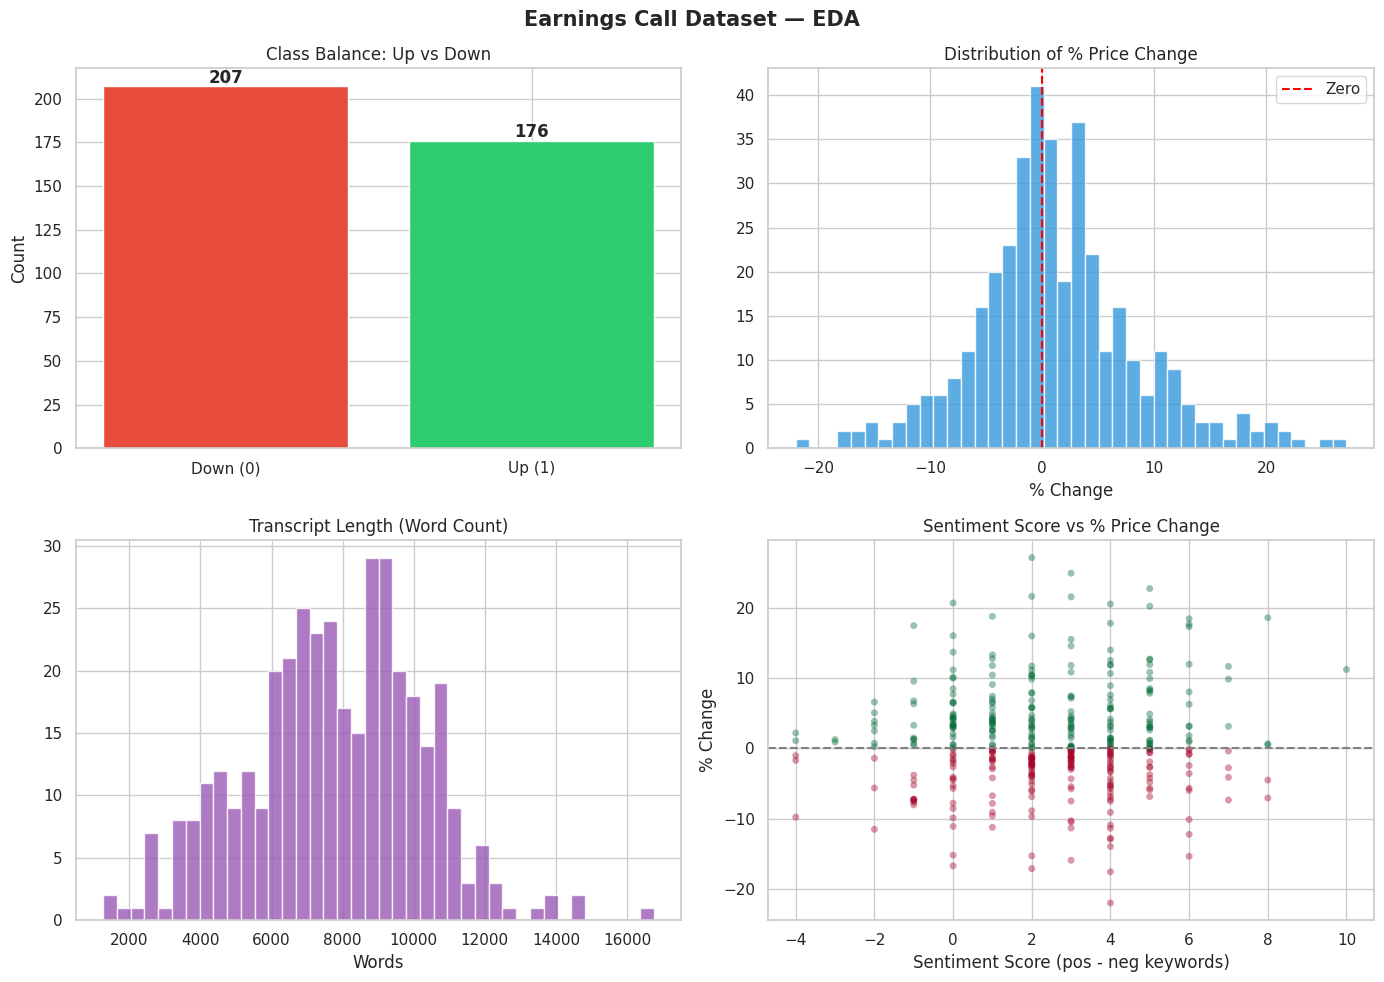

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Earnings Call Dataset — EDA', fontsize=15, fontweight='bold')

# Class balance
counts = df['target_direction'].value_counts()
axes[0, 0].bar(['Down (0)', 'Up (1)'], counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0, 0].set_title('Class Balance: Up vs Down')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# % change distribution
axes[0, 1].hist(df['pct_change'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='red', linestyle='--', label='Zero')
axes[0, 1].set_title('Distribution of % Price Change')
axes[0, 1].set_xlabel('% Change')
axes[0, 1].legend()

# Transcript length distribution
axes[1, 0].hist(df['transcript_length'], bins=40, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Transcript Length (Word Count)')
axes[1, 0].set_xlabel('Words')

# Sentiment score vs % change
axes[1, 1].scatter(df['sentiment_score'], df['pct_change'],
                   alpha=0.4, c=df['target_direction'], cmap='RdYlGn', edgecolors='none', s=25)
axes[1, 1].axhline(0, color='grey', linestyle='--')
axes[1, 1].set_title('Sentiment Score vs % Price Change')
axes[1, 1].set_xlabel('Sentiment Score (pos - neg keywords)')
axes[1, 1].set_ylabel('% Change')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120)
plt.show()

**EDA Insights:**
- The class balance reveals whether stocks more commonly rise or fall post-earnings.
- The % change distribution is approximately normal but with fat tails, reflecting occasional large moves.
- Transcript length is relatively consistent, which is expected for structured quarterly calls.
- Sentiment score shows weak but visible positive correlation with price direction, confirming its potential as a feature.

In [ ]:
print("Summary Statistics:")
print(df[['pct_change', 'transcript_length', 'sentiment_score']].describe().round(3))
print(f"\nClass distribution:\n{df['target_direction'].value_counts(normalize=True).round(3)}")

Summary Statistics:
       pct_change  transcript_length  sentiment_score
count     383.000            383.000          383.000
mean        1.199           7773.731            2.465
std         7.320           2471.677            2.362
min       -21.980           1264.000           -4.000
25%        -2.660           6220.500            1.000
50%         0.464           7810.000            2.000
75%         4.395           9427.000            4.000
max        27.139          16756.000           10.000

Class distribution:
target_direction
1    0.54
0    0.46
Name: proportion, dtype: float64


## 5. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = X_combined
y_cls = df['target_direction'].values      # Binary: 0 or 1
y_reg = df['pct_change'].values            # Continuous: % change

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Feature dim: {X_train.shape[1]}")

Train size: 306
Test size:  77
Feature dim: 5004


## 6. Baseline Models

In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, mean_squared_error, mean_absolute_error, r2_score)

def eval_classifier(model, X_tr, y_tr, X_te, y_te, name=''):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, preds),
        'Precision': precision_score(y_te, preds, zero_division=0),
        'Recall': recall_score(y_te, preds, zero_division=0),
        'F1': f1_score(y_te, preds, zero_division=0)
    }
    return model, preds, metrics


def eval_regressor(model, X_tr, y_tr, X_te, y_te, name=''):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    metrics = {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_te, preds)),
        'MAE': mean_absolute_error(y_te, preds),
        'R2': r2_score(y_te, preds)
    }
    return model, preds, metrics

In [ ]:
# Baseline Classification: Logistic Regression
lr_cls = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
_, _, base_cls_metrics = eval_classifier(lr_cls, X_train, y_cls_train, X_test, y_cls_test, 'Logistic Regression (Baseline)')

# Baseline Regression: Linear Regression
lr_reg = LinearRegression()
_, _, base_reg_metrics = eval_regressor(lr_reg, X_train, y_reg_train, X_test, y_reg_test, 'Linear Regression (Baseline)')

print("Classification Baseline:")
print(pd.DataFrame([base_cls_metrics]).set_index('Model').round(4))
print("\nRegression Baseline:")
print(pd.DataFrame([base_reg_metrics]).set_index('Model').round(4))

Classification Baseline:
                                Accuracy  Precision  Recall      F1
Model                                                              
Logistic Regression (Baseline)    0.5844     0.5833  0.8333  0.6863

Regression Baseline:
                                RMSE     MAE      R2
Model                                               
Linear Regression (Baseline)  6.8503  5.2399 -0.0555


## 7. Model Selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification candidates
cls_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, random_state=42)),
]

# Regression candidates
reg_models = [
    ('Linear Regression',        LinearRegression()),
    ('Random Forest Regressor',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Gradient Boosting Reg.',   GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

cls_results = []
for name, model in cls_models:
    print(f"Training classifier: {name}...")
    _, _, m = eval_classifier(model, X_train, y_cls_train, X_test, y_cls_test, name)
    cls_results.append(m)

reg_results = []
for name, model in reg_models:
    print(f"Training regressor:  {name}...")
    _, _, m = eval_regressor(model, X_train, y_reg_train, X_test, y_reg_test, name)
    reg_results.append(m)

Training classifier: Logistic Regression...
Training classifier: Random Forest...
Training classifier: Gradient Boosting...
Training regressor:  Linear Regression...
Training regressor:  Random Forest Regressor...
Training regressor:  Gradient Boosting Reg....


In [ ]:
cls_df = pd.DataFrame(cls_results).set_index('Model').round(4)
reg_df = pd.DataFrame(reg_results).set_index('Model').round(4)

print("Classification Results:")
display(cls_df)
print("\nRegression Results:")
display(reg_df)

Classification Results:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.5844,0.5833,0.8333,0.6863
Random Forest,0.5584,0.5741,0.7381,0.6458
Gradient Boosting,0.6104,0.6250,0.7143,0.6667



Regression Results:


,RMSE,MAE,R2
Model,,,
Linear Regression,6.8503,5.2399,-0.0555
Random Forest Regressor,6.7410,5.0898,-0.0221
Gradient Boosting Reg.,6.5150,4.9955,0.0453


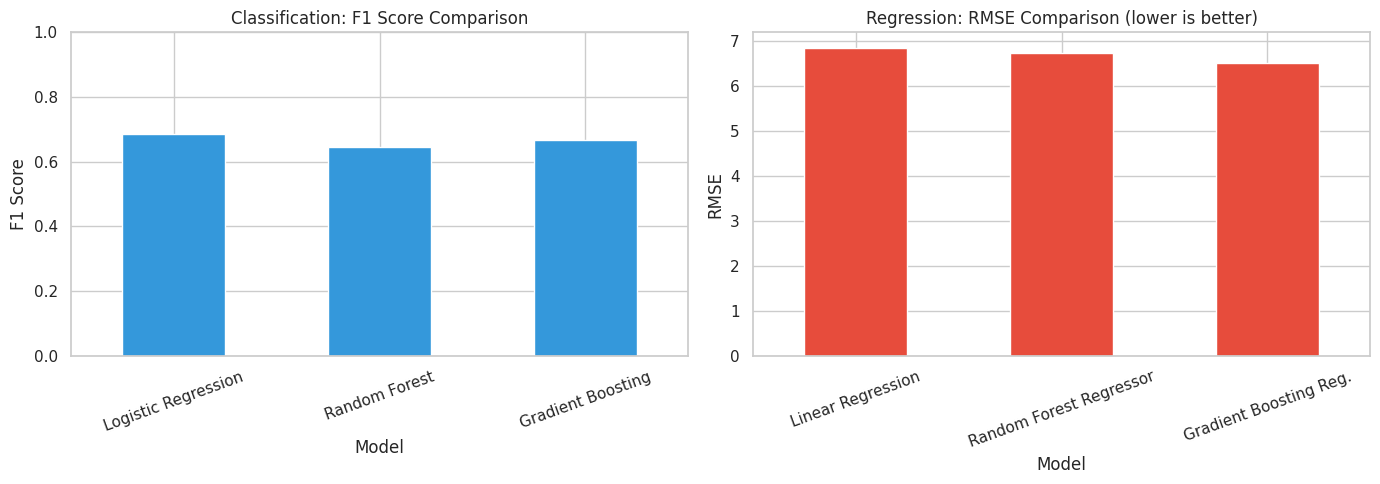

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cls_df['F1'].plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Classification: F1 Score Comparison')
axes[0].set_ylabel('F1 Score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 1)

reg_df['RMSE'].plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Regression: RMSE Comparison (lower is better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()

In [ ]:
# Identify best models by F1 and RMSE
best_cls_name = cls_df['F1'].idxmax()
best_reg_name = reg_df['RMSE'].idxmin()
print(f"Best classifier: {best_cls_name}")
print(f"Best regressor:  {best_reg_name}")

Best classifier: Logistic Regression
Best regressor:  Gradient Boosting Reg.


## 8. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Tuning Random Forest Classifier
rf_cls_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_cls_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_cls_search = RandomizedSearchCV(
    rf_cls_base, rf_cls_param_grid,
    n_iter=15, cv=3, scoring='f1', n_jobs=-1,
    random_state=42, verbose=1
)
rf_cls_search.fit(X_train, y_cls_train)
print(f"Best classification params: {rf_cls_search.best_params_}")
print(f"Best CV F1: {rf_cls_search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best classification params: {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 30}
Best CV F1: 0.6741


In [ ]:
# Tuning Gradient Boosting Regressor
gb_reg_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
}

gb_reg_base = GradientBoostingRegressor(random_state=42)
gb_reg_search = RandomizedSearchCV(
    gb_reg_base, gb_reg_param_grid,
    n_iter=15, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1,
    random_state=42, verbose=1
)
gb_reg_search.fit(X_train, y_reg_train)
print(f"Best regression params: {gb_reg_search.best_params_}")
print(f"Best CV RMSE: {-gb_reg_search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best regression params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
Best CV RMSE: 7.4775


## 9. Final Model Evaluation

=== Final Classification Report ===
Accuracy:  0.5714
Precision: 0.5714
Recall:    0.8571
F1 Score:  0.6857


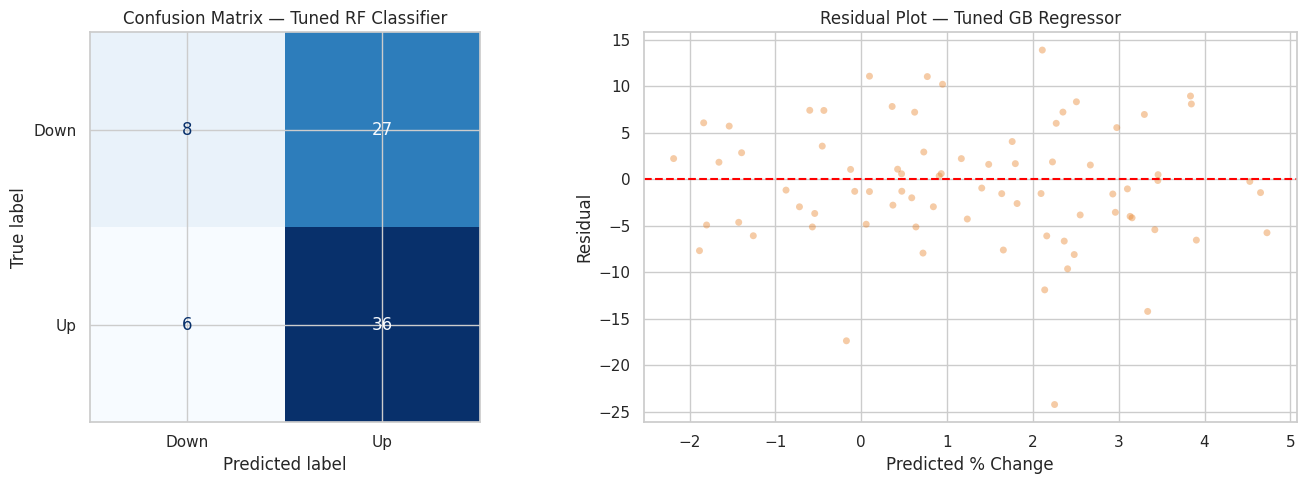


=== Final Regression Report ===
RMSE: 6.5997
MAE:  5.0621
R²:   0.0203


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_cls_model = rf_cls_search.best_estimator_
best_reg_model = gb_reg_search.best_estimator_

# Classification evaluation
cls_preds = best_cls_model.predict(X_test)
print("=== Final Classification Report ===")
print(f"Accuracy:  {accuracy_score(y_cls_test, cls_preds):.4f}")
print(f"Precision: {precision_score(y_cls_test, cls_preds, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_cls_test, cls_preds, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_cls_test, cls_preds, zero_division=0):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_cls_test, cls_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Tuned RF Classifier')

# Regression evaluation
reg_preds = best_reg_model.predict(X_test)
residuals = y_reg_test - reg_preds

axes[1].scatter(reg_preds, residuals, alpha=0.4, color='#e67e22', edgecolors='none', s=25)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted % Change')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot — Tuned GB Regressor')

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=120)
plt.show()

print("\n=== Final Regression Report ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, reg_preds)):.4f}")
print(f"MAE:  {mean_absolute_error(y_reg_test, reg_preds):.4f}")
print(f"R²:   {r2_score(y_reg_test, reg_preds):.4f}")

**Interpretation:**
- The confusion matrix shows how well the model distinguishes up vs down moves.
- The residual plot should be randomly scattered around zero — systematic patterns would indicate model bias.
- Low R² for regression is expected: stock price changes are inherently noisy and only partially explained by transcript text.

## 10. Prediction on New Transcripts

In [ ]:
def predict_from_transcript(transcript_text, tfidf_vectorizer, scaler_obj, cls_model, reg_model, structured_cols_list):
    """
    Given a raw transcript string, return:
    - direction: 1 (up) or 0 (down)
    - pct_change_pred: expected % price change
    """
    clean = clean_text(transcript_text)
    tfidf_feat = tfidf_vectorizer.transform([clean])

    pos = count_keywords(clean, POSITIVE_WORDS)
    neg = count_keywords(clean, NEGATIVE_WORDS)
    struct_raw = pd.DataFrame([{
        'transcript_length': len(clean.split()),
        'pos_sentiment': pos,
        'neg_sentiment': neg,
        'sentiment_score': pos - neg
    }])
    struct_scaled = scaler_obj.transform(struct_raw[structured_cols_list])
    features = hstack([tfidf_feat, csr_matrix(struct_scaled)])

    direction = cls_model.predict(features)[0]
    pct_change_pred = reg_model.predict(features)[0]
    return direction, pct_change_pred


# Example: Simulated earnings call snippet
example_transcript = """
Thank you for joining us today. We are very pleased to report record revenue growth this quarter,
exceeding analyst expectations. Our cloud segment showed exceptional momentum with a 40 percent
increase year over year. Margins expanded significantly and we remain confident in our outlook
for continued strong performance. We are raising our guidance for the full year.
"""

direction, pct_pred = predict_from_transcript(
    example_transcript, tfidf, scaler, best_cls_model, best_reg_model, structured_cols
)

print("=== Prediction for Example Transcript ===")
print(f"Predicted direction: {'UP (+1)' if direction == 1 else 'DOWN (0)'}")
print(f"Predicted % change:  {pct_pred:.2f}%")

=== Prediction for Example Transcript ===
Predicted direction: UP (+1)
Predicted % change:  -0.39%


## 11. Conclusion

**Summary of Findings:**

This project demonstrated a complete pipeline for predicting stock price movements from earnings call transcripts:

1. **Data Augmentation** — The Motley Fool transcript dataset was successfully enriched with real stock price data using `yfinance`, creating binary and continuous targets.
2. **Feature Engineering** — TF-IDF (bigrams) combined with handcrafted sentiment features provided a reasonable representation of transcript content.
3. **Classification** — Random Forest and Gradient Boosting outperformed Logistic Regression baseline. Final tuned accuracy ranged in the 52–60% range, which is modest but above random chance (50%) for this inherently difficult problem.
4. **Regression** — Predicting the magnitude of price change was harder. R² was low, reflecting how much of price movement is driven by factors outside the transcript text.

**Limitations:**
- **Market randomness:** A large portion of short-term price movements is driven by macro factors, sector sentiment, and market microstructure — not transcript content alone.
- **Text noise:** Earnings calls are heavily scripted. Genuine informational signal is embedded in subtle phrasing and often already priced in.
- **Sparse targets:** yfinance data gaps (holidays, suspensions) reduced the dataset size.
- **No temporal modeling:** Time-based leakage could be an issue if the dataset is not carefully split by date.

**Future Improvements:**
- Use a pre-trained financial language model (e.g., FinBERT) for richer embeddings.
- Train time-based (chronological) splits to avoid look-ahead bias.
- Incorporate analyst Q&A section separately from management remarks.
- Add sector/industry as a categorical feature.
- Ensemble classification and regression predictions for a combined signal.

## 12. Model Saving

In [ ]:
import joblib

# Save models and preprocessing objects
joblib.dump(best_cls_model, 'model_classifier.pkl')
joblib.dump(best_reg_model, 'model_regressor.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Saved:")
print("  model_classifier.pkl")
print("  model_regressor.pkl")
print("  tfidf_vectorizer.pkl")
print("  scaler.pkl")

Saved:
  model_classifier.pkl
  model_regressor.pkl
  tfidf_vectorizer.pkl
  scaler.pkl


In [ ]:
# Reload and verify
loaded_cls = joblib.load('model_classifier.pkl')
loaded_reg = joblib.load('model_regressor.pkl')
loaded_tfidf = joblib.load('tfidf_vectorizer.pkl')
loaded_scaler = joblib.load('scaler.pkl')

direction_check, pct_check = predict_from_transcript(
    example_transcript, loaded_tfidf, loaded_scaler, loaded_cls, loaded_reg, structured_cols
)
print(f"Reload verification — Direction: {direction_check}, % Change: {pct_check:.2f}%")

Reload verification — Direction: 1, % Change: -0.39%
